# Women Safety Risk Prediction using Machine Learning

**Dataset:** `Woman_Safety_Dataset_Management(5).csv`

This project follows the uploaded ML workflow:

**Load Dataset → Understand Data → Data Analysis → Visualization → Handle Missing Values → Analyze Outliers → Handle/Investigate Outliers → Encode Categorical Data → Scale Numerical Features → Train ML Model → Evaluate Model**

The workflow recommends `SimpleImputer` for missing values, IQR for outlier analysis, `OneHotEncoder`/`OrdinalEncoder` for categorical features, and `StandardScaler`/`MinMaxScaler` for numerical features.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

df = pd.read_csv("Woman_Safety_Dataset_Management(5).csv")
df.head()

,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp
0,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,Kolkata,Park Street,22.587501,88.359752,Domestic Violence,23,Afternoon,2.26,1.00,768,Stormy,0.85,Low,2025-05-14 12:40:25
1,ef4ba791-e5b5-4146-a3bb-c63e5d695e7c,Kolkata,Garia,22.565575,88.356876,Assault,4,Morning,1.84,2.01,626,Clear,0.92,Low,2024-11-02 08:14:54
2,6db79d9c-62d4-4c74-a2f2-295297dbc083,Bhopal,Kolar,23.242474,77.396845,Verbal Abuse,25,Afternoon,5.04,2.37,900,Clear,0.89,Low,2026-01-27 03:45:27
3,84fa6f88-339e-44b9-896a-6a548b8466c6,Mumbai,Kurla,18.997624,72.906211,Chain Snatching,19,Afternoon,2.94,6.16,114,Clear,0.58,Medium,2026-02-09 17:34:04
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,0.42,High,2025-02-16 06:47:57


## 1. Basic Data Understanding

In [22]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())

print("\nRisk level frequency:")
print(df["risk_level"].value_counts())

Shape: (20000, 15)

Columns:
['incident_id', 'city', 'area', 'latitude', 'longitude', 'crime_type', 'crime_count', 'time_of_day', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'weather_condition', 'safety_score', 'risk_level', 'incident_timestamp']

Data types:
incident_id                       str
city                              str
area                              str
latitude                      float64
longitude                     float64
crime_type                        str
crime_count                     int64
time_of_day                       str
lighting_score                float64
police_station_distance_km    float64
crowd_density                   int64
weather_condition                 str
safety_score                  float64
risk_level                        str
incident_timestamp                str
dtype: object

Missing values:
incident_id                   0
city                          0
area                          0
latitude              

In [23]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_id,20000,20000,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,20000,10,Bhopal,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,20000,50,Indiranagar,443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,20000.0,NaN,NaN,NaN,21.625279,5.430797,12.874962,17.385593,23.188318,26.842789,28.718786
longitude,20000.0,NaN,NaN,NaN,79.419284,4.313909,72.764977,77.207536,77.669767,80.949044,88.460186
crime_type,20000,10,Night Safety Complaint,2047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crime_count,20000.0,NaN,NaN,NaN,32.35685,17.146166,0.0,18.0,32.0,46.0,85.0
time_of_day,20000,5,Night,4061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lighting_score,20000.0,NaN,NaN,NaN,5.493725,2.592954,1.0,3.22,5.5,7.75,10.0
police_station_distance_km,20000.0,NaN,NaN,NaN,4.116744,2.23354,0.2,2.22,4.11,6.04,8.0


## 2. Data Analysis + Visualization

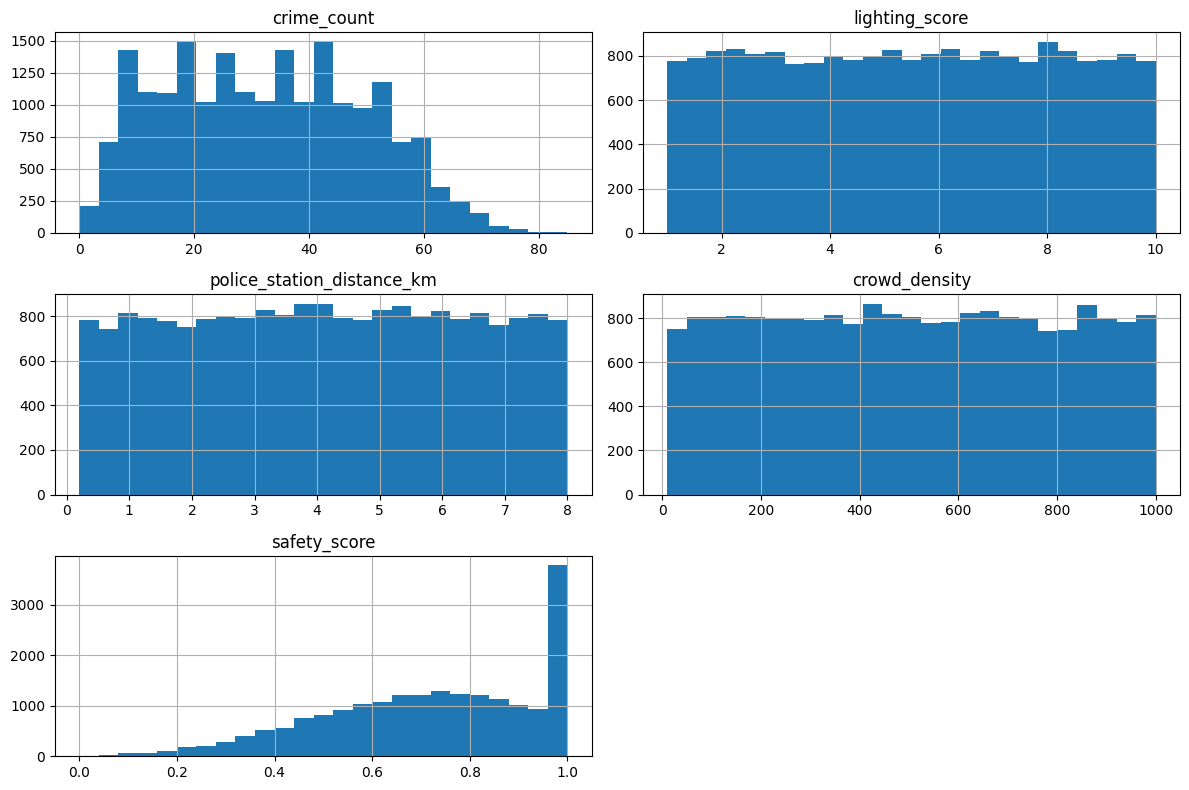

In [24]:
# Numerical distributions
numeric_cols = [
    "crime_count",
    "lighting_score",
    "police_station_distance_km",
    "crowd_density",
    "safety_score"
]

df[numeric_cols].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

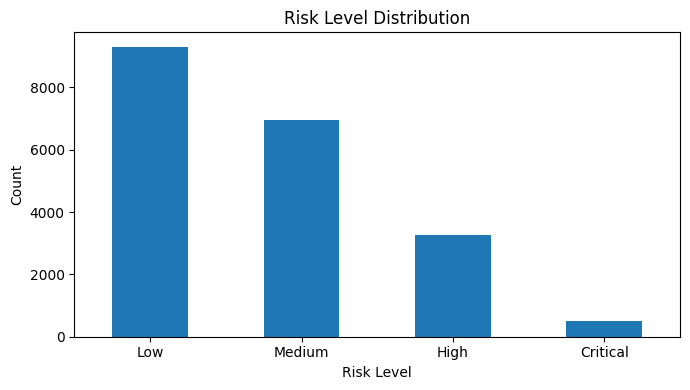

In [25]:
# Risk-level distribution
risk_counts = df["risk_level"].value_counts()

plt.figure(figsize=(7, 4))
risk_counts.plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


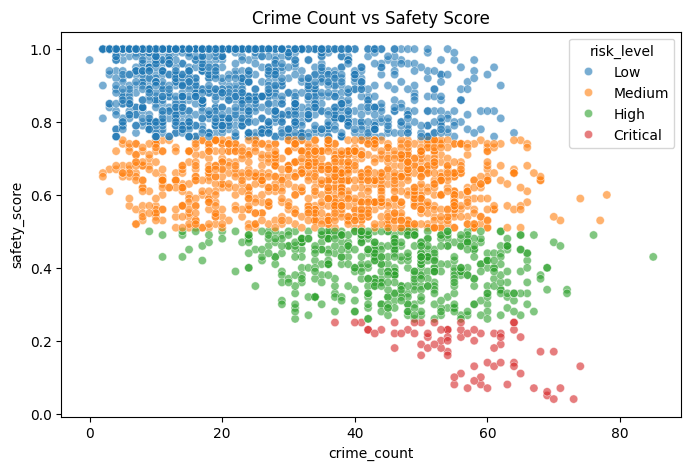

In [26]:
# Crime count vs safety score
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x="crime_count",
    y="safety_score",
    hue="risk_level",
    alpha=0.6
)
plt.title("Crime Count vs Safety Score")
plt.show()

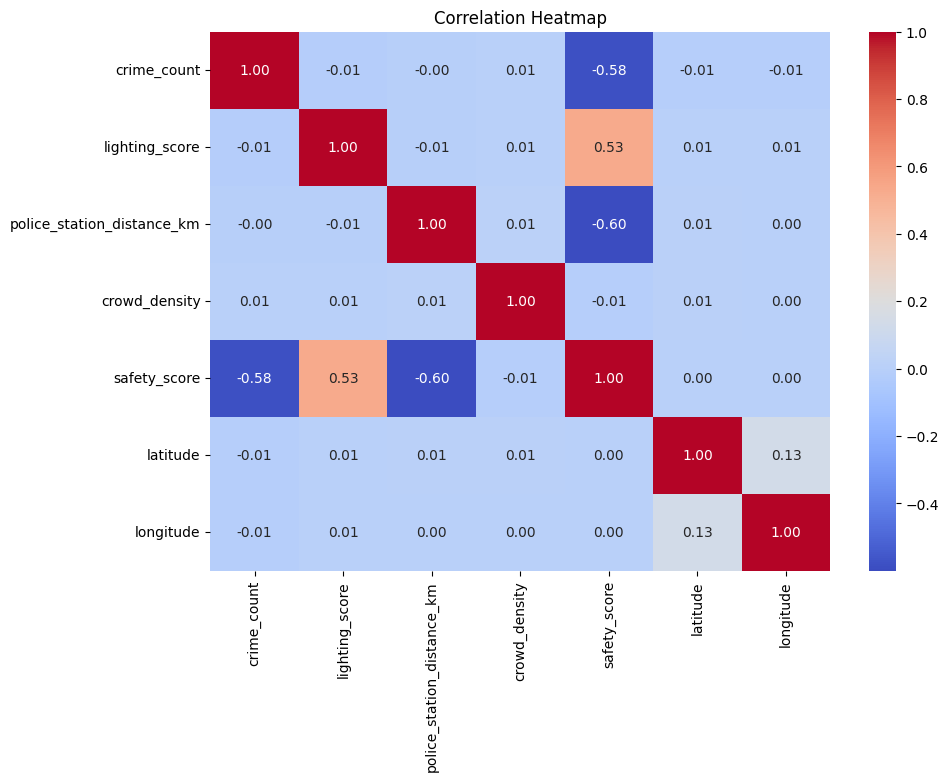

In [27]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[numeric_cols + ["latitude", "longitude"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 3. Missing Value Handling

The current dataset contains **no missing values**. We still include `SimpleImputer` in the ML preprocessing pipeline so the project remains robust if future data contains missing numerical or categorical values.

- Numerical: median
- Categorical: most frequent

In [28]:
print("Total missing values:", int(df.isnull().sum().sum()))

Total missing values: 0


## 4. Outlier Analysis using IQR

For each important numerical feature:

**IQR = Q3 − Q1**

**Lower Bound = Q1 − 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

Outliers are investigated rather than automatically deleted. In this dataset, longitude can contain valid geographic extremes, so blindly removing it would not be appropriate.

In [29]:
outlier_summary = []

for col in numeric_cols + ["latitude", "longitude"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_summary.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum())
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,crime_count,18.000000,46.000000,28.000000,-24.000000,88.000000,0
1,lighting_score,3.220000,7.750000,4.530000,-3.575000,14.545000,0
2,police_station_distance_km,2.220000,6.040000,3.820000,-3.510000,11.770000,0
3,crowd_density,259.000000,750.000000,491.000000,-477.500000,1486.500000,0
4,safety_score,0.560000,0.900000,0.340000,0.050000,1.410000,20
5,latitude,17.385593,26.842789,9.457196,3.199800,41.028583,0
6,longitude,77.207536,80.949044,3.741509,71.595272,86.561308,2014


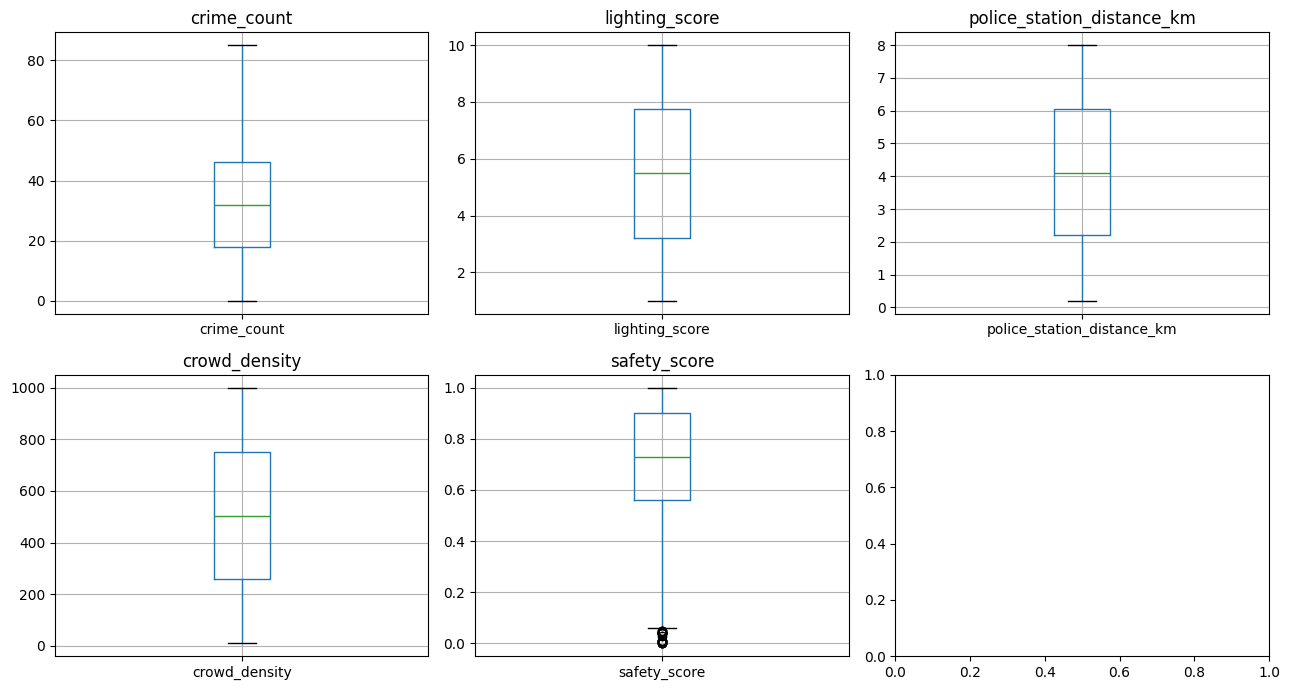

In [30]:
# Boxplots for visual outlier inspection
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 5. Prepare Data for Machine Learning

`risk_level` is the target.

`incident_id` is an identifier and is removed.

`incident_timestamp` is converted into useful time features:
- incident hour
- incident month
- incident day of week

`risk_level` is encoded with `LabelEncoder`.

### Leakage note

`safety_score` is highly related to `risk_level` and may be a derived score. To make the predictive experiment more meaningful, the main model excludes `safety_score` from the feature set. A separate comparison can include it.

In [31]:
data = df.copy()

# Convert timestamp into usable numerical features
timestamp = pd.to_datetime(data["incident_timestamp"], errors="coerce")
data["incident_hour"] = timestamp.dt.hour
data["incident_month"] = timestamp.dt.month
data["incident_dayofweek"] = timestamp.dt.dayofweek

# Remove ID, raw timestamp, and safety_score from the main experiment
data = data.drop(columns=[
    "incident_id",
    "incident_timestamp",
    "safety_score"
])

X = data.drop(columns=["risk_level"])
y = data["risk_level"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", list(label_encoder.classes_))
print("Feature shape:", X.shape)
X.head()

Target classes: ['Critical', 'High', 'Low', 'Medium']
Feature shape: (20000, 14)


,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,incident_hour,incident_month,incident_dayofweek
0,Kolkata,Park Street,22.587501,88.359752,Domestic Violence,23,Afternoon,2.26,1.00,768,Stormy,12,5,2
1,Kolkata,Garia,22.565575,88.356876,Assault,4,Morning,1.84,2.01,626,Clear,8,11,5
2,Bhopal,Kolar,23.242474,77.396845,Verbal Abuse,25,Afternoon,5.04,2.37,900,Clear,3,1,1
3,Mumbai,Kurla,18.997624,72.906211,Chain Snatching,19,Afternoon,2.94,6.16,114,Clear,17,2,0
4,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,6,2,6


## 6. Categorical Encoding + Feature Scaling

In [32]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

Categorical features: ['city', 'area', 'crime_type', 'time_of_day', 'weather_condition']
Numerical features: ['latitude', 'longitude', 'crime_count', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'incident_hour', 'incident_month', 'incident_dayofweek']


C:\Users\psaty\AppData\Local\Temp\ipykernel_13824\2974411512.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


## 7. Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


## 8. Logistic Regression Model

In [34]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    logistic_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Accuracy: 0.98575

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.86      0.92       100
        High       0.97      0.97      0.97       652
         Low       1.00      1.00      1.00      1860
      Medium       0.98      0.99      0.98      1388

    accuracy                           0.99      4000
   macro avg       0.99      0.95      0.97      4000
weighted avg       0.99      0.99      0.99      4000



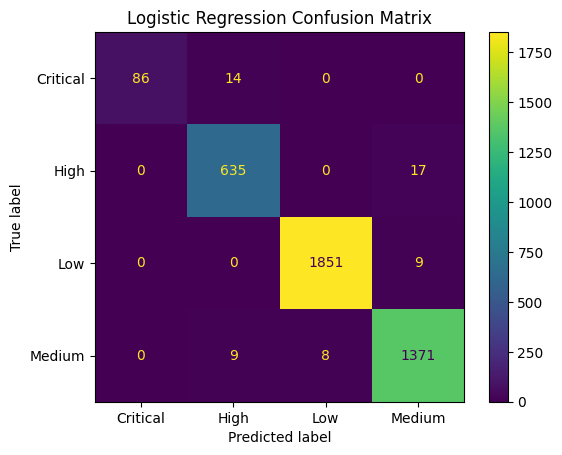

In [35]:
cm = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 9. Random Forest Model

In [36]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Accuracy: 0.89925

Classification Report:
              precision    recall  f1-score   support

    Critical       0.97      0.39      0.56       100
        High       0.88      0.75      0.81       652
         Low       0.95      0.96      0.95      1860
      Medium       0.85      0.92      0.88      1388

    accuracy                           0.90      4000
   macro avg       0.91      0.76      0.80      4000
weighted avg       0.90      0.90      0.90      4000



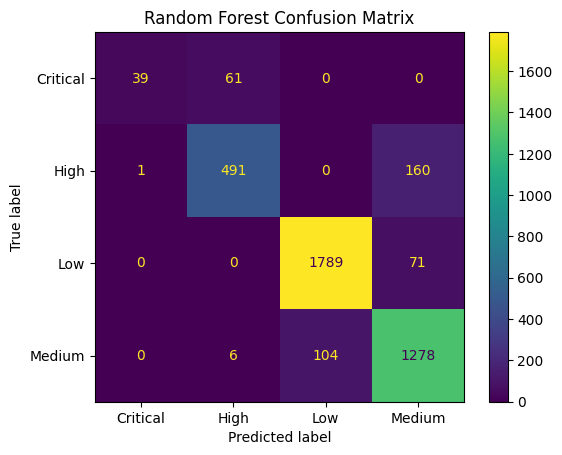

In [37]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## 10. Compare Models

In [38]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ]
}).sort_values("Accuracy", ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.98575
1,Random Forest,0.89925


## 11. Optional Experiment: Include Safety Score

Because `safety_score` is strongly related to `risk_level`, including it may make the task artificially easy. This experiment demonstrates the effect rather than using it in the main model.

In [39]:
# Optional comparison with safety_score included
data_leakage_test = df.copy()

timestamp = pd.to_datetime(
    data_leakage_test["incident_timestamp"],
    errors="coerce"
)

data_leakage_test["incident_hour"] = timestamp.dt.hour
data_leakage_test["incident_month"] = timestamp.dt.month
data_leakage_test["incident_dayofweek"] = timestamp.dt.dayofweek

data_leakage_test = data_leakage_test.drop(columns=[
    "incident_id",
    "incident_timestamp"
])

X_leak = data_leakage_test.drop(columns=["risk_level"])
y_leak = label_encoder.transform(data_leakage_test["risk_level"])

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak,
    y_leak,
    test_size=0.20,
    random_state=42,
    stratify=y_leak
)

cat_leak = X_leak.select_dtypes(include="object").columns.tolist()
num_leak = X_leak.select_dtypes(include=np.number).columns.tolist()

pre_leak = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_leak),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_leak)
])

leak_model = Pipeline([
    ("preprocessor", pre_leak),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

leak_model.fit(Xl_train, yl_train)
leak_pred = leak_model.predict(Xl_test)

print("Accuracy with safety_score included:",
      accuracy_score(yl_test, leak_pred))

C:\Users\psaty\AppData\Local\Temp\ipykernel_13824\1889816290.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_leak = X_leak.select_dtypes(include="object").columns.tolist()


Accuracy with safety_score included: 1.0


## 12. Final Conclusion

This project demonstrates the complete student ML workflow:

1. Load the Women Safety dataset.
2. Understand shape, types, statistics, missing values, duplicates and unique values.
3. Visualize distributions, categories, relationships and correlations.
4. Handle missing values using `SimpleImputer` inside the preprocessing pipeline.
5. Analyze numerical outliers using the IQR method.
6. Encode categorical variables using `OneHotEncoder`.
7. Encode the target using `LabelEncoder`.
8. Scale numerical features using `StandardScaler`.
9. Train Logistic Regression and Random Forest models.
10. Compare accuracy and classification reports.

For a production-quality system, additional validation would be needed, including time-based validation, monitoring, fairness analysis, and validation on newly collected data.